# 6.2 ***图像卷积***

### 6.2.1 *二维互相关运算*

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
d2l.corr2d(X, K)

### 6.2.2 *卷积层*

In [ ]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return d2l.corr2d(x, self.weight) + self.bias

### 6.2.3 *图像中目标的边缘检测*

In [ ]:
# 6*8像素的黑白图像，其中第2列到第5列是黑色（0），其他是白色（1）
X = torch.ones((6,8))
X[:, 2:6] = 0
X

In [ ]:
# 高度为1，宽度为2的卷积核K
K = torch.tensor([[1.0, -1.0]])
K

In [ ]:
Y = d2l.corr2d(X, K)
Y

In [ ]:
d2l.corr2d(X.t(), K)

### 6.2.4 *卷积核*

In [ ]:
conv2d = nn.Conv2d(1, 1, kernel_size=(1, 2), bias=False)

# 这个二维卷积层使用四维输入和输出，分别对应批量大小、通道数、高度和宽度
# 其中批量大小和通道数都是1
conv2d.weight.data.reshape((1, 2))
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f"epoch {i+1}, loss {l.sum():.3f}")


In [ ]:
conv2d.weight.data.reshape((1, 2))

# 6.3 ***填充和步幅***

In [ ]:
# 卷积时会丢失边缘像素，可以使用填充（padding）来解决
# 填充（padding）是在输入的边界填充0，使输出的尺寸与输入相同
# 因此，卷积核一般选择奇数大小，如3x3、5x5等
import torch
from torch import nn

def comp_conv2d(conv2d, X):
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    return Y.reshape(Y.shape[2:])

conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape


In [ ]:
conv2d = nn.Conv2d(1, 1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

In [ ]:
# 步幅（stride）是卷积核在输入上移动的步长
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

In [ ]:
conv2d = nn.Conv2d(1, 1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

# 6.4 ***多输入多输出通道***

### 6.4.1 *多输入通道*

In [ ]:
# 输入包含多个通道时，卷积核的通道数与输入通道数相同
# 多输入通道的互相关运算就是每个通道与其对应卷积核的通道进行互相关运算，然后将结果相加
# 2x3x3的输入通道与2x2x2的卷积核进行互相关运算，输出1x2x2的输出通道

import torch
from d2l import torch as d2l

def corr2d_multi_in(X, K):
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

In [ ]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
                  [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

### 6.4.2 *多输出通道*

In [ ]:
# 为了获得多通道的输出，只有一个与输入通道数相同的卷积核是不够的
# 需要多个卷积核，每个卷积核的通道数与输入通道数相同
# 每个输出通道对应的卷积核会与所有输入通道进行互相关运算
# 在得到全部卷积核的输出通道后，将它们按通道维度进行拼接，就得到了多通道的输出

def corr2d_multi_in_out(X, K):
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [ ]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

In [ ]:
corr2d_multi_in_out(X, K)

### 6.4.3 *$1\times 1$卷积层*

In [ ]:
# 失去卷积的能力：在高度和宽度的维度上，识别相邻元素相互作用的能力
# 所以，计算只发生在通道上

def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

# 6.5 ***汇聚层***

### 6.5.1 ***最大汇聚层和平均汇聚层***

In [ ]:
# 与互相关运算类似，汇聚层每次从输入张量的一个固定形状窗口中提取元素
# 但，汇聚层不包含参数，通常我们计算汇聚窗口内元素的最大值或平均值
# 汇聚层的主要优点之一是减轻卷积层对位置的过度敏感

import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

In [ ]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

In [ ]:
pool2d(X, (2, 2), 'avg')

### 6.5.2 *填充和步幅*

In [ ]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

In [ ]:
pool2d = nn.MaxPool2d(3)
pool2d(X)

In [ ]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

In [ ]:
pool2d = nn.MaxPool2d((2, 3), padding=(0, 1), stride=(2, 3))
pool2d(X)

### 6.5.3 *多通道*

In [ ]:
# 汇聚层在每个输入通道上单独运算，而不是像卷积层那样在通道上对输入进行汇总

X = torch.cat((X, X + 1), 1)
X

In [ ]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

# 6.6 ***卷积神经网络（LeNet）***

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

### 6.6.1 ***LeNet模型***

In [2]:
# nn.Conv2d的参数：
# in_channels: 输入通道数
# out_channels: 输出通道数
# kernel_size: 卷积核大小
# stride: 步幅
# padding: 填充
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

# 6.6.2 ***模型训练***

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

loss 0.461, train acc 0.827, test acc 0.779
8157.8 examples/sec on cpu


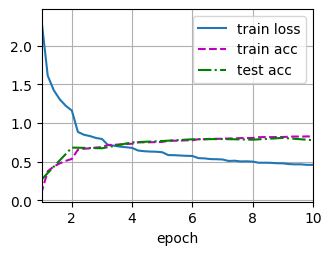

In [4]:
lr, num_epochs = 0.9, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())